In [ ]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
#load dataset
df=pd.read_csv('/content/vehicle_condition_knn.csv')

In [ ]:
df.describe()

,vehicle_age_years,engine_vibration,battery_health_pct,mileage_km_per_l,service_count
count,365.000000,365.000000,365.000000,365.000000,365.000000
mean,59.865068,6.485342,72.081151,6.070548,8.539068
std,40.607930,2.153766,16.858064,1.520852,5.180492
min,-1.870000,2.870000,39.160000,2.940000,-0.020000
25%,23.510000,4.450000,55.060000,4.740000,3.550000
50%,49.990000,6.230000,74.100000,6.190000,7.710000
75%,102.500000,8.670000,88.530000,7.550000,13.840000
max,145.440000,11.180000,100.040000,8.680000,19.660000


In [ ]:
df.shape

(365, 6)

In [ ]:
print("No.of records:",df.duplicated().sum())

No.of records: 5


In [ ]:
#remove duplicate records
df.drop_duplicates(inplace=True)
df.shape

(360, 6)

In [ ]:
print("No.of records:",df.duplicated().sum())

No.of records: 0


In [ ]:
#idetify null values
df.isnull().sum()

,0
vehicle_age_years,0
engine_vibration,0
battery_health_pct,0
mileage_km_per_l,0
service_count,0
class,0


<Axes: ylabel='vehicle_age_years'>

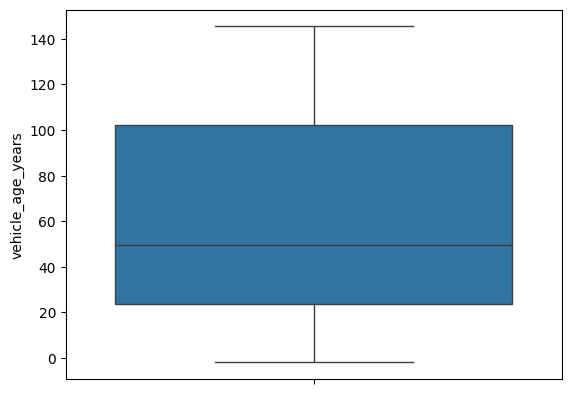

In [ ]:
#identify outliers
sns.boxplot(df['vehicle_age_years'])

<Axes: ylabel='engine_vibration'>

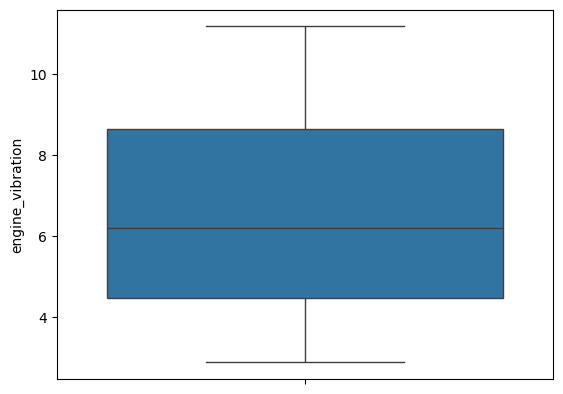

In [ ]:
#identfy outliers in engine_vibration
sns.boxplot(df['engine_vibration'])

<Axes: ylabel='battery_health_pct'>

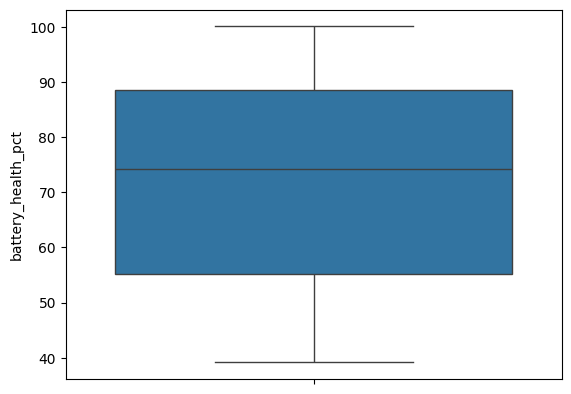

In [ ]:
#identify battery_health_pct
sns.boxplot(df['battery_health_pct'])

<Axes: ylabel='mileage_km_per_l'>

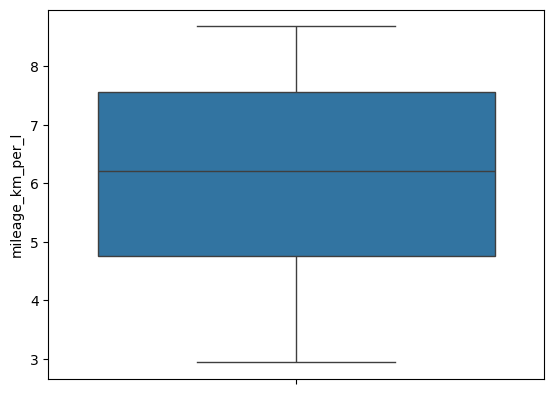

In [ ]:
#identify petal width
sns.boxplot(df['mileage_km_per_l'])

<Axes: ylabel='service_count'>

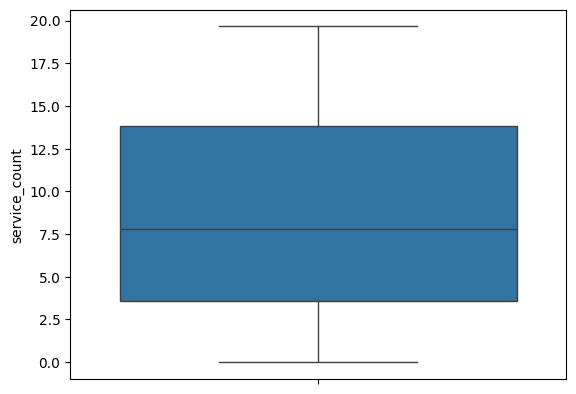

In [ ]:
#identify petal width
sns.boxplot(df['service_count'])

In [ ]:
#label encoding for target
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['class']=le.fit_transform(df['class'])
df.head()


,vehicle_age_years,engine_vibration,battery_health_pct,mileage_km_per_l,service_count,class
0,16.02,4.31,92.22,7.59,13.99,0
1,91.96,7.65,58.14,5.13,2.46,2
2,37.74,5.24,83.19,7.85,16.11,0
3,99.44,8.18,50.76,3.64,3.80,2
4,114.13,8.92,52.12,3.36,1.98,2


In [ ]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [ ]:
#split the data into training and testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=15)

In [ ]:
#satndardization
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
#model building
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
#predictions on test data
y_pred=knn.predict(x_test)

In [ ]:
#evaluation metrics
accuracy_score(y_test,y_pred)
classification_report(y_test,y_pred)
confusion_matrix(y_test,y_pred)

array([[27,  0,  0],
       [ 0, 19,  0],
       [ 0,  0, 26]])

<Axes: >

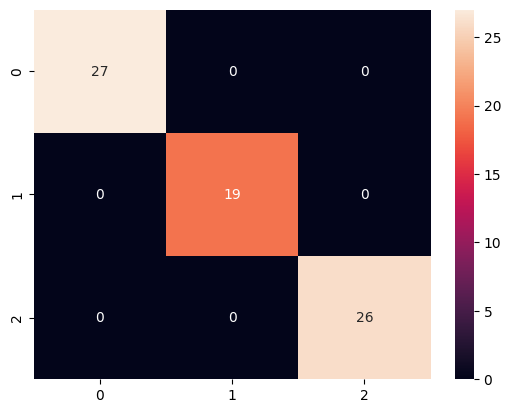

In [ ]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score
y_pred = knn.predict(x_test)
y_proba = knn.predict_proba(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
roc_auc = roc_auc_score(
y_test,
y_proba,
multi_class='ovr'
)
print("ROC-AUC Score:", roc_auc)

Accuracy: 1.0
ROC-AUC Score: 1.0


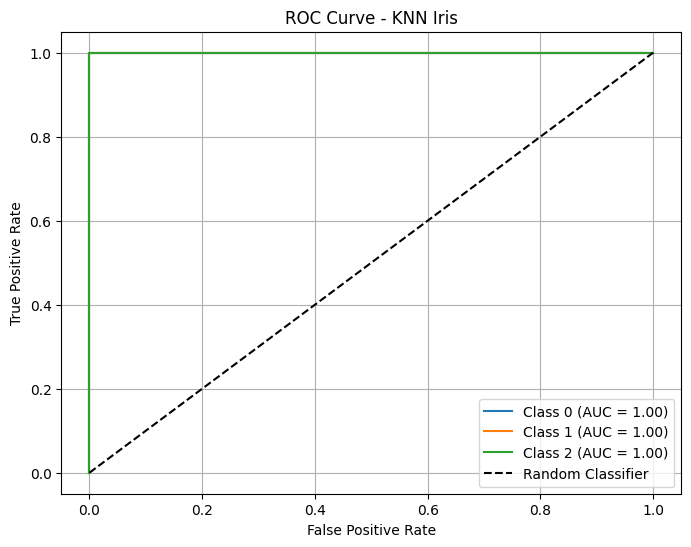

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Predict probabilities
y_proba = knn.predict_proba(x_test)
# Convert test labels into binary form
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(
        fpr, tpr,
        label=f'Class {i} (AUC = {auc_score:.2f})'
    )
# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN Iris')
plt.legend()
plt.grid()
plt.show()

In [ ]:
overall_auc = roc_auc_score(
    y_test_bin,
    y_proba,
    multi_class='ovr'
)

print("Overall ROC-AUC:", overall_auc)

Overall ROC-AUC: 1.0
